In [1]:
%matplotlib inline
from pylab import *

In [2]:
from deficit_defs_2025_02_25 import *

Splikes version  0.1.4
Plasticnet version  0.1.13
macOS-15.4.1-arm64-arm-64bit
Base Image File: asdf/bbsk081604_all_scale2.asdf


In [3]:
number_of_processes=8
ray.init(num_cpus=number_of_processes)

2025-05-05 09:44:40,546	INFO worker.py:1852 -- Started a local Ray instance.


Python version:,3.12.6
Ray version:,2.44.1


In [4]:
base_sim_dir=f"sims-2025-05-05"
if not os.path.exists(base_sim_dir):
    os.mkdir(base_sim_dir)
print(base_sim_dir)

sims-2025-05-05


In [5]:
def default_post(number_of_neurons):
    post=pn.neurons.linear_neuron(number_of_neurons)
    post+=pn.neurons.process.sigmoid(0,50)
    return post

def default_bcm(pre,post,orthogonalization=True):
    c=pn.connections.BCM(pre,post,[-.01,.01],[.1,.2])
    
    if orthogonalization:
        c+=pn.connections.process.orthogonalization(10*minute)

    c.eta=2e-6
    c.tau=15*pn.minute   

    return c

In [12]:
dt=200*ms
rf_size=19
blur=b=1
eta=4e-6

seq=pn.Sequence()

im=pi5.filtered_images(
                    base_image_file,
                    {'type':'blur','size':b},
                    {'type':'norm'},
                    {'type':'dog','sd1':1,'sd2':3},   
                    )
    
pre1=pn.neurons.natural_images(im,
                                rf_size=rf_size,
                                time_between_patterns=dt,
                                            verbose=False)

sigma=0.1
pre1+=pn.neurons.process.add_noise_normal(0,sigma)

pre=pre1

number_of_neurons=12

post=default_post(number_of_neurons)
c=default_bcm(pre,post)
c.eta=eta

total_time=8*day
save_interval=1*hour
sim=pn.simulation(total_time)
sim.dt=dt

sim.monitor(post,['output'],save_interval)
sim.monitor(c,['weights','theta'],save_interval)

rf_diameter=rf_size

#deg_per_rf=8 # from Bergh et al 2010
deg_per_rf=1 # from (0.5 – 2 degrees near the fovea) http://www.scholarpedia.org/article/Receptive_field
deg_per_pixel=deg_per_rf/rf_diameter  

cpd=2**linspace(-4,3,20)
k_mat=2*pi*cpd*deg_per_pixel
    
sim+=pn.grating_response(print_time=False,
                    k_mat=k_mat,
                        )


seq+=sim,[pre,post],[c]


seq.run(display_hash=True)

final_weights=c.weights.copy()

sfname=f"{base_sim_dir}/rf1.asdf"
pn.save(sfname,seq) 

 [#############################100% (ETA: 0.0 s)#############################].] Sequence Time Elapsed...36.00 s


In [14]:
R=Results(sfname)

subR=Struct()
subR.t=R.t/day
t=subR.t

subR.y=R.y
subR.θ=R.θ

#idx1,idx2=[_[1] for _ in R.sequence_index]

# subR.ODI=R.ODI
subR.ORI=R.ORI
subR.theta_mat=R.theta_mat
subR.k_mat=R.k_mat
#subR.LSFV=R.LSFV
subR.SF_Var=R.SF_Var
subR.max_SF=R.max_SF
subR.sfname=sfname
subR.sequence_index=R.sequence_index
subR.idx=[0]+[_[-1] for _ in R.sequence_index]
subR.W=R.W[subR.idx,::]

In [33]:
R.W.shape

(193, 12, 361)

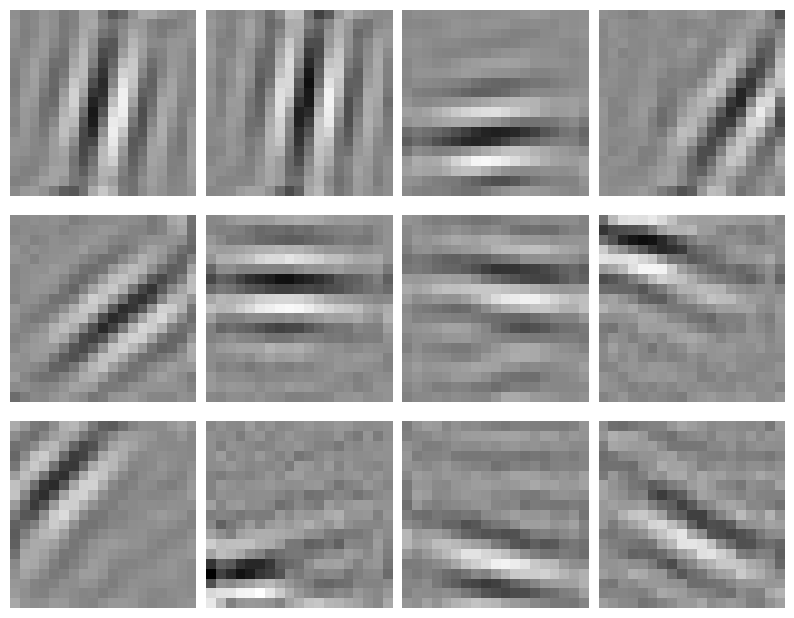

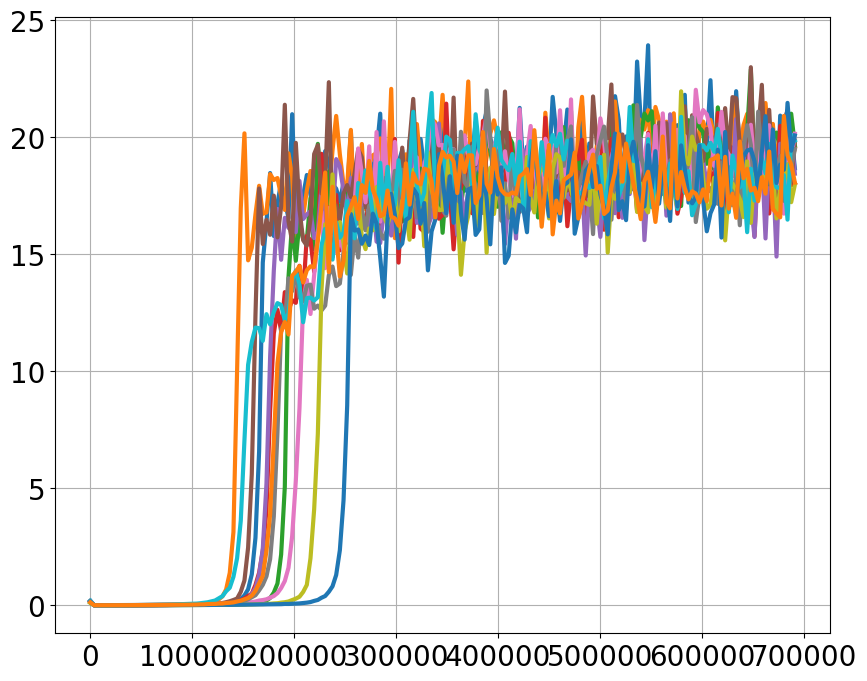

In [15]:
figure()
im=R.W_image()
imshow(im,cmap=cm.gray)
grid(None)
axis('off')

figure()
plot(R.t,R.θ);

In [16]:
theta_mat=subR.theta_mat
k_mat=subR.k_mat


In [18]:
t,y=R.all_responses[0]
y.shape   # SF, theta, channels, neurons, time

(20, 24, 1, 12, 193)

In [19]:
# end time
y=y[:,:,:,:,-1]
y.shape

(20, 24, 1, 12)

In [21]:
idx=[]
for n in range(y.shape[3]):
    idx+=[argmax(y[:,:,0,n])]  # max across all angles and SF
idx

[397, 397, 407, 399, 402, 384, 385, 386, 377, 405, 362, 388]

In [22]:
i,j=meshgrid(range(len(theta_mat)),range(len(k_mat)))
_S=Storage()

max_k_idx=[]
max_theta_idx=[]

for n in range(y.shape[3]):
    max_k_idx=j.ravel()[idx[n]]
    max_theta_idx=i.ravel()[idx[n]]
    max_k=k_mat[max_k_idx]
    max_theta=theta_mat[max_theta_idx]

    _S+=max_k,max_theta,max_k_idx,max_theta_idx

max_k,max_theta,max_k_idx,max_theta_idx=_S.arrays()
max_k,max_theta

(array([1.2296992 , 1.2296992 , 1.2296992 , 1.2296992 , 1.2296992 ,
        1.2296992 , 1.2296992 , 1.2296992 , 0.95256167, 1.2296992 ,
        0.95256167, 1.2296992 ]),
 array([101.73913043, 101.73913043, 180.        , 117.39130435,
        140.86956522,   0.        ,   7.82608696,  15.65217391,
        133.04347826, 164.34782609,  15.65217391,  31.30434783]))

Text(0.5, 1.0, 'Mean SF 3.58 cpd')

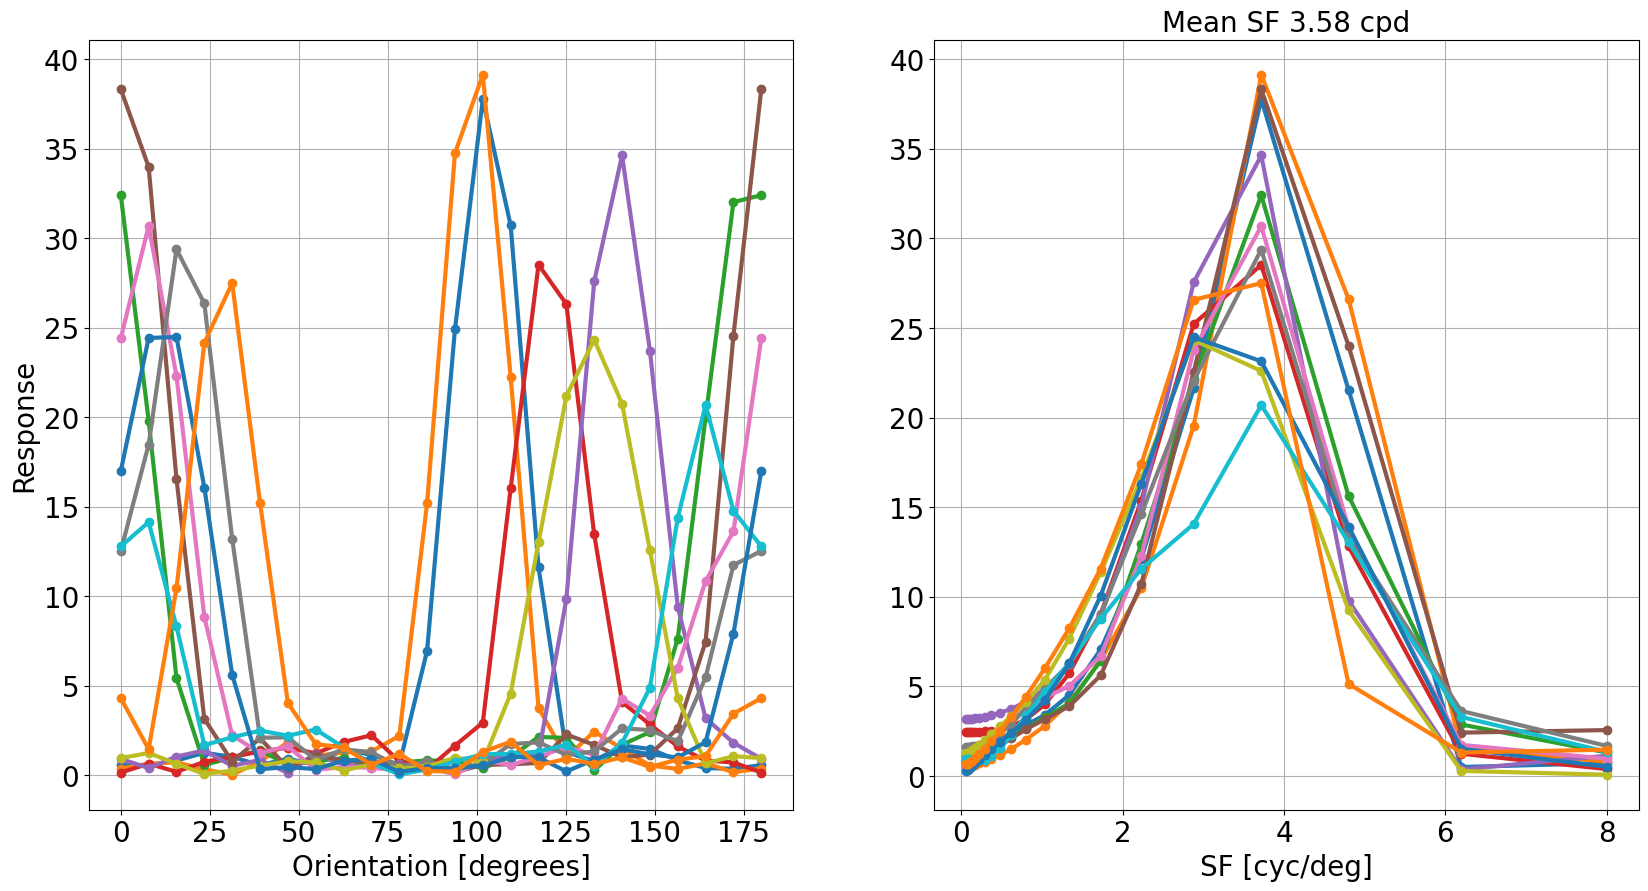

In [28]:
figure(figsize=(20,10))
subplot(1,2,1)

for n in range(y.shape[3]):
    plot(theta_mat,y[:,:,0,n][max_k_idx[n],:],'-o')
xlabel('Orientation [degrees]')
ylabel('Response')



cpd=k_mat/(2*pi*deg_per_pixel)
max_cpd=max_k/(2*pi*deg_per_pixel)
subplot(1,2,2)
for n in range(y.shape[3]):
    plot(cpd,y[:,:,0,n][:,max_theta_idx[n]],'-o')

xlabel('SF [cyc/deg]')
title(f'Mean SF {mean(max_cpd):.2f} cpd')

$\text{Visual Angle (°)} = 5 \times \left(10^{\text{logMAR}} \right) / 60$


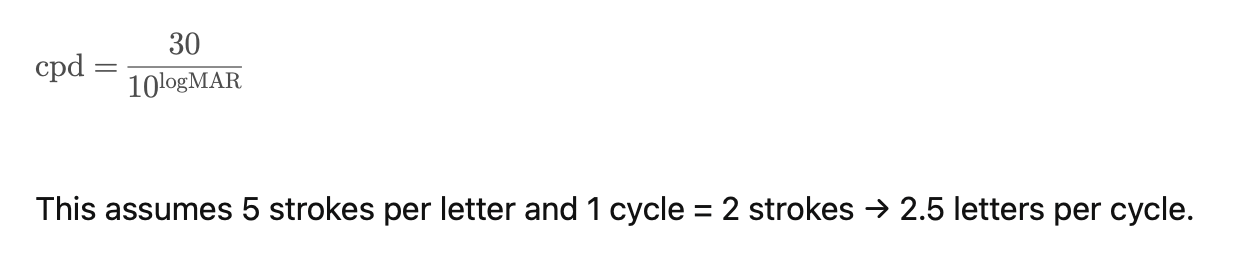

[@aghajariPopulationSpatialFrequency2020]

population spatial frequency between 1-5 cpd.



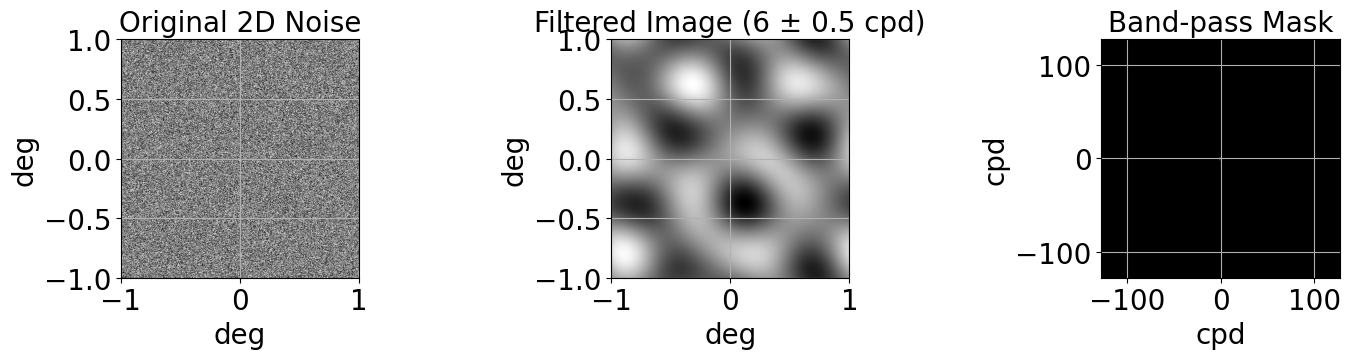

In [31]:
import numpy as np
import matplotlib.pyplot as plt

def bandpass_filter_2d_noise(size=512, width_deg=2.0, band_cpd=4.0, bandwidth=0.5):
    # 1. Create 2D spatial grid (degrees)
    x = np.linspace(-width_deg/2, width_deg/2, size)
    y = np.linspace(-width_deg/2, width_deg/2, size)
    dx = x[1] - x[0]  # resolution in degrees
    X, Y = np.meshgrid(x, y)

    # 2. Generate 2D uniform noise
    noise = np.random.uniform(-1, 1, (size, size))

    # 3. Compute 2D FFT and frequency grids (in cpd)
    fft_noise = np.fft.fftshift(np.fft.fft2(noise))
    fx = np.fft.fftshift(np.fft.fftfreq(size, d=dx))  # cycles per degree (x)
    fy = np.fft.fftshift(np.fft.fftfreq(size, d=dx))  # cycles per degree (y)
    FX, FY = np.meshgrid(fx, fy)
    R = np.sqrt(FX**2 + FY**2)  # radial spatial frequency (cpd)

    # 4. Construct a circular band-pass filter
    bandpass_mask = np.logical_and(R >= (band_cpd - bandwidth), R <= (band_cpd + bandwidth))

    # 5. Apply filter in frequency domain
    filtered_fft = fft_noise * bandpass_mask

    # 6. Inverse FFT to get filtered image
    filtered_img = np.fft.ifft2(np.fft.ifftshift(filtered_fft)).real

    return noise, filtered_img, bandpass_mask, fx, fy

# Example usage
noise, filtered, mask, fx, fy = bandpass_filter_2d_noise(size=512, band_cpd=1.4, bandwidth=0.1)

# Plot results
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(noise, cmap='gray', extent=[-1, 1, -1, 1])
plt.title("Original 2D Noise")
plt.xlabel("deg"); plt.ylabel("deg")

plt.subplot(1, 3, 2)
plt.imshow(filtered, cmap='gray', extent=[-1, 1, -1, 1])
plt.title("Filtered Image (6 ± 0.5 cpd)")
plt.xlabel("deg"); plt.ylabel("deg")

plt.subplot(1, 3, 3)
plt.imshow(mask, cmap='gray', extent=[fx[0], fx[-1], fy[0], fy[-1]])
plt.title("Band-pass Mask")
plt.xlabel("cpd"); plt.ylabel("cpd")

plt.tight_layout()
plt.show()

In [32]:
filtered.shape

(512, 512)

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import zoom

def upsample_and_multiply(modulator_19x19, filtered_image):
    # Get target size from the filtered image
    target_shape = filtered_image.shape  # e.g., (512, 512)

    # Compute zoom factors for each dimension
    zoom_factors = (
        target_shape[0] / modulator_19x19.shape[0],
        target_shape[1] / modulator_19x19.shape[1]
    )

    # Upsample using bilinear interpolation (order=1)
    modulator_resized = zoom(modulator_19x19, zoom_factors, order=1)

    # Element-wise multiply with the filtered image
    modulated_output = filtered_image * modulator_resized

    return modulated_output, modulator_resized

In [37]:
out,W_512=upsample_and_multiply(R.W[-1,-1,:].reshape((19,19)), filtered)

In [39]:
out

array([[ 6.07053954e-06,  3.57979668e-07, -6.62441880e-06, ...,
         4.37403761e-05,  5.71099115e-05,  7.19613607e-05],
       [ 6.89278297e-06,  2.43492406e-06, -3.19650841e-06, ...,
         3.54941650e-05,  4.76193064e-05,  6.11428067e-05],
       [ 7.30643057e-06,  3.99838919e-06, -3.88887080e-07, ...,
         2.75876133e-05,  3.85431603e-05,  5.08148915e-05],
       ...,
       [ 1.22649753e-04,  1.30434648e-04,  1.37567840e-04, ...,
         1.17038572e-04,  1.34744956e-04,  1.52868879e-04],
       [ 1.18246116e-04,  1.26615631e-04,  1.34310461e-04, ...,
         9.99293607e-05,  1.16641731e-04,  1.33777892e-04],
       [ 1.12627783e-04,  1.21578963e-04,  1.29833770e-04, ...,
         8.38357235e-05,  9.95632770e-05,  1.15720257e-04]])

In [41]:
import numpy as np
from scipy.ndimage import zoom

def process_weighted_images(W, filtered_image):
    """
    W: (N, 361) array, each row is a flattened 19x19 modulator
    filtered_image: 2D array (e.g., 512x512)
    
    Returns:
        result: (N,) array of summed values after filtering
    """
    N = W.shape[0]
    output = np.zeros(N)
    target_shape = filtered_image.shape
    zoom_factors = (target_shape[0] / 19, target_shape[1] / 19)

    for i in range(N):
        # Reshape to 19x19
        modulator = W[i].reshape(19, 19)
        # Upsample to match filtered image size
        modulator_resized = zoom(modulator, zoom_factors, order=1)
        # Element-wise multiplication
        product = filtered_image * modulator_resized
        # Sum the result
        output[i] = np.sum(product)

    return output

In [44]:
output=process_weighted_images(R.W[-1,::], filtered)
output

array([ -2.33558886,  17.98679389,  31.26497544,  18.25795325,
         1.82009044,  33.36220186,  -1.14070403,  -3.37276678,
       -28.71740306,  -8.30993182, -14.12750248,  -6.22266877])

In [79]:
cpd=2**linspace(-4,3,20)
v=np.flip(linspace(0.3,1,len(cpd)))
neuron_max_outputs=[]
for j,_cpd in tqdm(enumerate(cpd),total=len(cpd)):
    outputs=[]
    for i in tqdm(range(30)):
        noise, filtered, mask, fx, fy = bandpass_filter_2d_noise(size=512, band_cpd=1.4, bandwidth=0.1)
        outputs.append(process_weighted_images(R.W[-1,::], filtered))
    outputs=array(outputs)  
    outputs=outputs.max(axis=0)
    neuron_max_outputs.append(outputs)
    #plot(outputs,'o-',lw=1,color=Blues2(v[j]),label=str(cpd));

neuron_max_outputs=array(neuron_max_outputs)
neuron_max_outputs.shape

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

...

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

(20, 12)

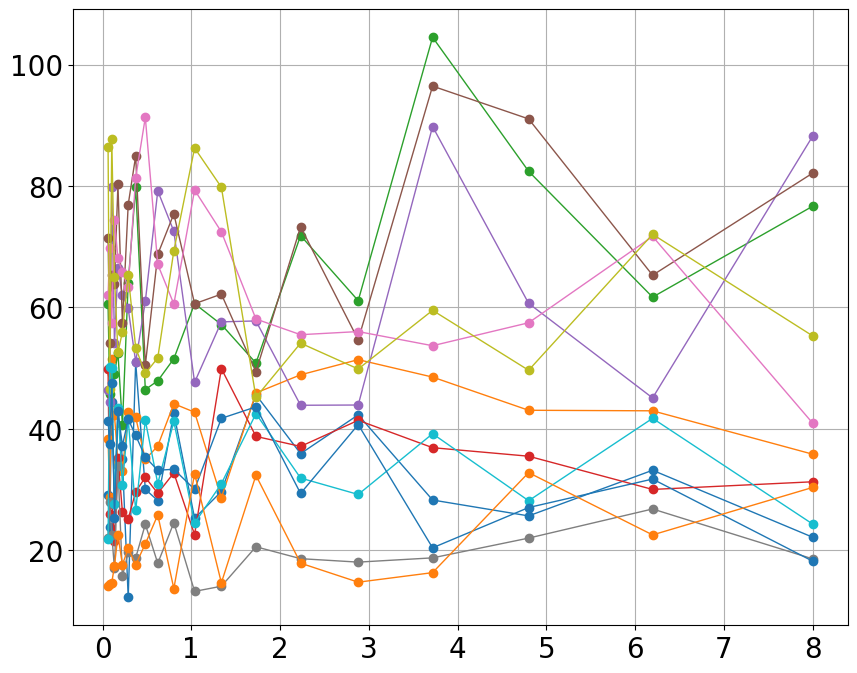

In [80]:
plot(cpd,neuron_max_outputs,'o-',lw=1,);

## More debugging

In [81]:
w1=array([ 4.90236415e-02,  7.93870608e-03, -4.16506478e-02, -6.34312232e-02,
       -5.98503584e-03,  3.26234891e-02,  7.18151232e-02,  6.52509720e-02,
       -7.70724229e-02, -2.07819832e-01, -1.75046421e-01,  4.44596529e-02,
        1.94503809e-01,  1.76879948e-01,  8.93292816e-02,  3.17252921e-02,
        3.90203528e-03,  6.17866208e-03, -8.81824723e-04,  3.49902478e-02,
        3.76822587e-04, -2.53689119e-02, -3.85104806e-02, -2.91532046e-02,
       -9.45653851e-03,  3.41989684e-02,  9.46671862e-02, -1.24617298e-02,
       -1.59877376e-01, -1.28177748e-01,  1.61404375e-02,  7.77118965e-02,
        2.73062661e-02, -4.45749987e-02, -6.86872530e-02, -5.39535885e-02,
       -2.89150046e-02, -2.95968262e-03,  1.34609338e-02, -1.53901594e-02,
       -3.52184637e-02, -3.68404353e-02, -3.49405815e-02, -1.64501363e-02,
        4.30198730e-02,  8.21809554e-02, -1.99198646e-02, -1.43995905e-01,
       -8.28578193e-02,  7.30847525e-02,  1.29417298e-01,  3.28094812e-02,
       -6.04457326e-02, -5.91038670e-02, -3.75398500e-02, -2.75822593e-02,
       -3.26021027e-02, -1.01419523e-02, -7.90783929e-03, -1.59359176e-02,
       -3.60747750e-02, -2.28972996e-02,  3.09008734e-02,  9.86473358e-02,
        9.66109274e-02, -6.05074610e-02, -1.96160706e-01, -1.05357412e-01,
        1.22628858e-01,  2.02365829e-01,  9.88972410e-02, -4.34554938e-02,
       -6.58259369e-02, -2.67645491e-02, -2.02022859e-02, -2.70283990e-02,
       -1.25942846e-02,  1.70303588e-02,  1.59489814e-02, -6.70404880e-03,
       -5.94567980e-03,  4.34552884e-02,  1.20846349e-01,  9.46756323e-02,
       -8.99934159e-02, -2.23245835e-01, -1.20129661e-01,  1.30561616e-01,
        2.35136780e-01,  1.18410285e-01, -5.04227227e-02, -8.44922030e-02,
       -2.15088501e-02, -5.29309539e-04, -1.45075678e-02,  1.34688853e-03,
        3.32251192e-02,  4.64501025e-02, -2.34162686e-03, -1.30460695e-02,
        3.99266348e-02,  1.29078050e-01,  8.46598986e-02, -1.44930250e-01,
       -2.58471540e-01, -1.03052688e-01,  1.78169714e-01,  2.65854655e-01,
        1.07974048e-01, -7.25419022e-02, -1.04341937e-01, -2.34521503e-02,
        1.16910633e-02, -3.15971281e-02,  4.26881658e-03,  3.01493948e-02,
       -2.40720189e-03, -5.18401118e-02, -6.06528260e-02,  2.31143575e-02,
        1.35660957e-01,  5.60345131e-02, -1.92368255e-01, -2.96520562e-01,
       -7.24584174e-02,  2.57098460e-01,  3.01572104e-01,  9.56601047e-02,
       -1.16409898e-01, -1.30653157e-01, -2.21367591e-02,  2.47391257e-02,
       -7.52910862e-02,  1.21850261e-02,  1.56474509e-02, -2.52945728e-02,
       -8.81979671e-02, -8.13966382e-02,  4.09217530e-02,  1.65125540e-01,
        6.58596146e-02, -2.29060277e-01, -3.08289786e-01, -8.66987346e-03,
        3.20508236e-01,  3.07704790e-01,  3.68309187e-02, -1.73472606e-01,
       -1.42537953e-01,  1.68503028e-02,  7.40048973e-02, -6.12933272e-02,
        2.53511591e-02,  1.69656455e-02, -2.48524987e-02, -8.22248706e-02,
       -5.92383427e-02,  8.86048357e-02,  1.85281736e-01,  5.81078298e-02,
       -2.42769534e-01, -2.88897140e-01,  5.93627377e-02,  3.50109462e-01,
        2.75763301e-01, -2.71219944e-02, -2.21072115e-01, -1.35749471e-01,
        8.10887871e-02,  1.25538222e-01, -4.72912555e-02,  2.42574417e-02,
        2.52590076e-02, -1.14089166e-02, -4.27354492e-02, -1.21609410e-02,
        9.45344712e-02,  1.50533460e-01, -2.35393152e-02, -2.67230858e-01,
       -2.45340266e-01,  9.96865796e-02,  3.35057426e-01,  1.99887320e-01,
       -1.02003498e-01, -2.33032550e-01, -1.05769861e-01,  1.16230595e-01,
        1.15856374e-01, -7.39384408e-02,  3.68414647e-02,  2.11384332e-02,
       -2.82722727e-02, -4.85473992e-02,  2.80614513e-03,  9.77803524e-02,
        1.21846683e-01, -7.03782596e-02, -2.83753872e-01, -1.68017585e-01,
        1.81604301e-01,  3.22346710e-01,  1.47883641e-01, -1.24883025e-01,
       -2.02487462e-01, -5.38189485e-02,  1.22580534e-01,  7.81353703e-02,
       -8.88692244e-02,  1.01210648e-02, -1.57411389e-02, -4.74490156e-02,
       -5.45945702e-02, -8.63674068e-04,  1.21481443e-01,  1.02955210e-01,
       -1.00698240e-01, -2.53886071e-01, -8.43464385e-02,  2.46822641e-01,
        2.99976008e-01,  8.89109300e-02, -1.19602734e-01, -1.59716776e-01,
       -4.11623815e-02,  9.60029535e-02,  6.49311954e-02, -7.03954696e-02,
       -1.02232500e-02, -3.06239501e-02, -1.86456421e-02, -2.38369673e-02,
        2.20013304e-02,  1.01014429e-01,  7.75702885e-02, -1.16430706e-01,
       -2.41423752e-01, -6.32920099e-02,  2.15464470e-01,  2.37155232e-01,
        1.63436279e-02, -1.56859282e-01, -1.59333267e-01, -3.67064164e-02,
        5.88948654e-02,  4.81283233e-02, -5.41092001e-02, -2.63209405e-02,
        1.38637361e-02,  1.47271582e-02, -3.08619415e-04,  3.09920255e-02,
        7.17876322e-02,  5.55096555e-02, -8.13031233e-02, -2.00202805e-01,
       -4.35563730e-02,  1.87736570e-01,  1.81977555e-01, -1.46642455e-02,
       -1.66865976e-01, -1.42952241e-01, -5.63166065e-04,  5.86851696e-02,
        1.90373619e-02, -4.72219759e-02, -1.12160487e-02,  4.09640571e-02,
        4.69296701e-02,  9.11893281e-03,  3.70453529e-02,  6.20174927e-02,
        2.79272220e-02, -8.29052550e-02, -1.32263821e-01,  2.20281231e-02,
        1.85442766e-01,  1.81028189e-01,  1.54053838e-02, -1.28232148e-01,
       -1.18982771e-01,  1.15561268e-02,  6.10507937e-02,  3.02235031e-03,
       -4.74048193e-02, -1.36155337e-02,  3.44019670e-02,  1.47471802e-02,
       -2.59328050e-03,  2.58475801e-02,  5.59725355e-02, -2.93766942e-04,
       -8.80213957e-02, -8.67908208e-02,  2.55508530e-02,  1.71085661e-01,
        1.60693486e-01,  1.81579275e-02, -1.00849854e-01, -1.01744007e-01,
        1.13212928e-02,  5.38919182e-02,  4.28009020e-03, -5.72788057e-02,
        1.01566747e-02,  3.84690823e-02, -7.30965866e-03, -2.63881870e-02,
        3.85160676e-03,  4.06698315e-02,  3.25947776e-03, -9.42555435e-02,
       -8.44901803e-02,  1.73732737e-02,  8.53224961e-02,  7.42598291e-02,
       -3.33819131e-02, -1.00413386e-01, -6.27662033e-02, -7.21401058e-03,
        5.11259594e-02,  2.66860972e-02, -3.44095022e-02,  1.47968190e-02,
        2.58699863e-02, -1.65965312e-03, -1.91964998e-02,  2.59836013e-02,
        6.15889520e-02,  1.66016999e-02, -6.21880214e-02, -3.71995834e-02,
        3.45374354e-02,  4.96025036e-02, -2.50797798e-02, -1.08958278e-01,
       -1.14162268e-01, -5.87646750e-02,  1.11617211e-02,  3.84915250e-02,
        4.33691082e-02,  2.01470107e-02,  1.87257613e-02,  2.34278849e-02,
        4.35027262e-03, -2.54834600e-03,  5.40979241e-03, -2.82530410e-02,
       -8.92983785e-02, -7.40223659e-02,  4.55769503e-02,  1.54526937e-01,
        1.62784274e-01,  4.59478779e-02, -7.42695302e-02, -8.05140424e-02,
       -5.74765590e-02, -2.65263326e-02,  2.72411690e-02,  6.53081731e-02,
        3.71135882e-02]).reshape(19,19)

w0=array([-5.57064983e-03, -5.25139784e-03,  3.82961103e-03, -1.31036367e-03,
        9.71002066e-03,  8.75814076e-03,  8.90791349e-03,  9.94796880e-03,
       -9.95003802e-03,  7.05959669e-04, -9.62945230e-03,  7.93922916e-03,
        9.89852213e-03,  1.14170987e-04,  1.01844828e-03,  5.74019670e-03,
        5.56537742e-03, -1.35158379e-04, -2.96038965e-04,  7.17092214e-03,
       -6.69884285e-03,  3.75408610e-03,  3.83967182e-03, -1.66973338e-03,
        7.49491287e-03, -6.23744675e-03,  6.18617248e-03, -4.30660324e-03,
       -9.68274100e-03, -8.04901521e-03, -3.02789967e-03, -1.74855001e-03,
        3.91419959e-03,  8.34983835e-03, -7.96976118e-04, -7.40062746e-03,
        9.03545516e-03,  6.64053883e-03,  6.23773227e-03, -4.34505694e-03,
        2.34797988e-04, -8.70775740e-03, -2.51596575e-03, -7.93121891e-03,
       -2.23379408e-03, -3.35779777e-03,  4.42873340e-03,  1.35732452e-03,
        4.28652564e-04, -5.65075085e-03,  5.73465891e-03, -9.69732811e-03,
       -2.66299132e-04,  4.51045368e-03, -1.29340662e-03,  4.34460868e-03,
       -7.58844723e-03, -4.06058187e-03, -2.65265676e-03,  7.60096589e-04,
       -9.10865642e-03, -6.38947935e-03,  6.02636220e-03,  9.60662338e-03,
        6.93142383e-03,  4.26158605e-04, -1.76411783e-03, -3.43140908e-03,
       -1.26232768e-03, -6.75098733e-03, -7.65970536e-03, -1.48593084e-04,
       -9.05360687e-03, -5.22146390e-03, -7.78592511e-03, -9.48722056e-03,
       -5.45687838e-03, -4.23407472e-03,  3.02112436e-03, -5.65452280e-04,
        7.77044514e-04, -2.95389788e-03, -4.71747664e-03, -7.42427365e-03,
       -3.05241294e-03,  6.70230000e-03, -8.98639806e-03, -6.52158652e-03,
       -4.53347512e-03,  8.42656786e-03,  3.85456989e-03,  4.98164606e-03,
       -5.50302406e-03, -8.53973195e-03,  1.44615284e-03,  7.55804298e-03,
       -6.17370729e-03,  8.27808563e-03, -7.01119523e-04,  3.62676124e-03,
        1.32105590e-03, -2.45810153e-03, -3.06893768e-03, -9.60568225e-03,
        5.19759992e-03,  9.29966533e-04, -2.42326985e-03,  1.30515831e-03,
        1.50605731e-03,  4.82476046e-03,  4.31686831e-03, -1.05249477e-03,
       -4.56066890e-03,  8.46546692e-03,  5.53825097e-03,  4.22045240e-03,
       -8.39677789e-03, -8.92676565e-03,  1.78701641e-03,  1.78698809e-03,
        8.30764707e-03, -1.66710510e-03,  7.48429932e-03,  5.67145841e-03,
       -9.93498813e-03,  9.16523391e-03,  4.53322364e-03,  8.42639746e-03,
       -3.79974580e-03,  2.18954818e-03, -2.32384785e-03,  6.13798941e-03,
       -6.83244761e-03, -1.02534716e-03,  2.86455552e-03,  8.12610704e-03,
        3.30187086e-03,  6.37205932e-03,  1.36662557e-03, -8.44131422e-03,
       -9.89550879e-05, -2.58995116e-03, -8.86159408e-03, -7.91891039e-03,
        9.15164258e-03,  6.61068565e-03,  9.61259616e-04,  5.86704694e-03,
        4.93077664e-03, -1.38701814e-03,  1.32080481e-04,  2.31191979e-03,
        2.60386443e-03,  7.07082728e-04,  1.14436832e-04, -3.37852496e-03,
       -4.55250644e-03,  3.74374784e-03, -9.67873281e-03,  9.32673735e-03,
       -2.85922250e-04, -2.16664085e-03,  9.47092816e-03,  7.16556275e-03,
        9.09185906e-03, -5.38131783e-04,  3.22134082e-03, -7.40810648e-03,
        7.42439856e-03,  8.99334682e-03, -7.36518792e-03,  6.44227032e-04,
        2.03657741e-03,  3.68356022e-03,  4.68829315e-04, -1.59783907e-03,
       -6.73659021e-03, -7.62965334e-03,  1.24142960e-03,  8.21041788e-03,
       -3.67840341e-03, -3.30791888e-03,  4.90434911e-03,  6.32327123e-03,
       -6.39986053e-03,  6.54734349e-03, -3.93042380e-03,  8.77490417e-03,
        4.94384909e-03, -9.38564889e-03,  1.69725446e-04,  6.12634964e-03,
        3.69010975e-03,  5.77647049e-03,  6.34232914e-03, -3.83996147e-03,
        3.21562747e-03,  8.11661328e-03, -6.54898605e-03, -8.74772426e-03,
        7.54876954e-03,  5.24010868e-03,  3.61472017e-03, -4.51876031e-03,
       -2.08905892e-04, -5.42787348e-03, -7.63752075e-03, -7.34178828e-03,
        3.12672162e-04, -3.15666266e-03, -1.38632687e-03,  3.58435443e-03,
        4.59284097e-03, -9.19615789e-03,  4.74049303e-03, -2.04873122e-03,
        5.77650748e-03,  2.40785947e-03, -3.63795292e-03,  8.37489913e-03,
       -3.72129869e-03,  1.21805822e-03,  2.57083731e-03,  9.84792687e-03,
       -8.78399838e-03, -8.41925347e-03,  1.88077408e-03, -3.71860116e-04,
        9.16213720e-03, -8.93065239e-03, -8.29480964e-04, -2.82391946e-03,
        6.27414266e-04,  4.59990924e-03, -6.18254714e-03, -8.44760434e-03,
       -6.85758187e-04,  3.79560635e-03, -6.92087775e-03, -6.99414385e-03,
       -3.90881771e-03,  6.56232433e-03, -2.81628786e-03, -1.05798587e-03,
       -3.38295590e-03,  8.78715648e-03, -2.18230416e-03, -5.54793444e-03,
        1.05734693e-03, -7.09133793e-03, -6.31497684e-03,  2.40644103e-03,
        7.20508979e-04, -2.64427556e-03,  9.96318157e-03,  1.83763909e-03,
        7.23437273e-03,  1.19180288e-03, -5.33213028e-03,  4.16828934e-03,
        6.70172802e-03, -8.00455834e-03,  7.47267804e-03, -4.15723435e-03,
       -5.74800715e-03,  4.87627910e-03,  1.18043532e-03,  4.12447754e-03,
        9.93193223e-03,  5.53922015e-03,  1.08102392e-03, -6.71169074e-03,
       -7.68169908e-03, -2.68751558e-03, -8.15743701e-03,  5.53533928e-04,
       -8.29570993e-03, -6.36679942e-03,  2.52632174e-03,  7.99691293e-03,
       -7.20884890e-04,  1.81641333e-03,  9.05667370e-04, -8.96433578e-03,
        6.04856064e-03, -1.91531434e-03, -6.55445402e-03, -4.19788693e-03,
        7.59558151e-03,  6.02657187e-03,  9.73970240e-04,  6.48140353e-03,
        4.34837769e-03,  4.39261012e-03, -8.97615335e-03,  1.72072415e-03,
       -6.86711123e-04, -3.91826746e-03,  9.62173243e-03, -9.97179826e-03,
        6.17231359e-03,  5.20466417e-03, -8.49798218e-04, -5.47058684e-03,
       -3.15789273e-03, -3.32861941e-03, -3.71789511e-03,  2.94240445e-03,
       -9.70499198e-03, -9.48942432e-03,  7.85267160e-03, -6.26515352e-03,
       -5.21685329e-03,  5.11894435e-03,  1.81672438e-03,  1.53078060e-03,
       -3.13584337e-03, -2.12862463e-03, -3.06231159e-04, -9.27576940e-03,
       -1.63721605e-03,  4.04345823e-03, -4.95476155e-03, -5.09266489e-03,
        1.29850767e-03,  3.57448514e-03, -2.02408427e-03, -9.21916504e-03,
       -7.60351984e-03,  9.18400159e-03, -2.25623251e-03, -2.59336474e-03,
       -1.62875390e-03,  2.27119153e-03,  2.19840879e-03, -4.60527261e-03,
       -1.03259357e-03, -7.37989161e-03,  6.89486131e-03, -6.34905860e-03,
        2.89788758e-03,  6.24297156e-03,  2.85811489e-03,  5.51116829e-03,
       -2.44103972e-03, -2.62018838e-03, -6.06887485e-04, -5.59064457e-03,
       -3.19302857e-03,  3.91058367e-03,  5.83010763e-03, -5.95661574e-03,
       -5.83229289e-03, -9.27985591e-04, -6.07524379e-03,  8.76064595e-03,
       -3.61394236e-03, -5.29774251e-03, -3.59110633e-04,  3.39806766e-03,
        1.36915266e-03]).reshape((19,19))

w1b=array([-4.83534808e-02, -4.03858808e-02, -5.39636592e-02, -3.19559077e-02,
       -2.78836320e-02, -2.98342892e-02, -2.38441318e-02, -8.97396071e-03,
       -1.23421544e-02,  3.50109033e-03,  1.00031280e-02, -2.26650854e-03,
       -4.87331274e-03, -1.02439753e-02, -2.35656730e-02, -3.69496729e-02,
       -5.16809402e-02, -4.94059954e-02, -5.62431028e-02, -1.35875612e-02,
       -1.99753778e-02, -9.03306909e-03, -1.01553596e-02, -1.37524421e-02,
       -1.94776537e-03,  8.08173068e-03, -1.00040446e-04,  2.81883943e-03,
        6.84781436e-03,  7.86899861e-03,  5.75904284e-03,  1.93679358e-03,
        4.79110091e-04, -3.31650399e-03, -9.52006288e-03, -1.23696752e-02,
       -3.30488588e-02, -4.33555200e-02,  6.30154124e-03,  9.77450585e-03,
       -1.83779704e-03, -8.38164103e-03,  4.51413961e-03, -5.85945162e-04,
        3.25329803e-03,  1.35601894e-02,  8.01920965e-03,  1.98220372e-02,
        2.91709706e-02,  1.79384478e-02,  1.83806175e-02,  1.86792330e-02,
        1.92254688e-03, -1.12556542e-02, -9.14311059e-03, -1.06066547e-02,
       -1.64285408e-02,  2.70030025e-02,  1.95825362e-02,  9.13720841e-03,
        5.49343828e-03,  1.28975702e-02,  1.76617501e-02,  1.65911693e-02,
        1.71579193e-02,  1.57456876e-02,  2.04559268e-02,  1.72877393e-02,
        1.49258205e-02,  2.94929701e-02,  1.17985047e-02,  5.31613364e-03,
        4.58585389e-03,  1.00245364e-02,  4.56732783e-03,  1.28769409e-03,
        2.64133695e-02,  1.86186265e-02,  1.14768878e-02,  6.01983962e-03,
        1.97641364e-02,  1.16791552e-02,  3.13348794e-02,  3.27938826e-02,
        2.49841742e-02,  2.27178923e-02,  3.48355707e-02,  1.81219839e-02,
        2.05571218e-02,  2.14245454e-02,  1.38856624e-02,  1.24191593e-02,
        9.86423757e-03,  1.21080827e-02,  1.47626147e-02,  4.19187092e-02,
        1.78105339e-02,  2.26784808e-02,  1.90526776e-02,  1.21199958e-02,
        2.67007076e-02,  2.89726819e-02,  1.75853362e-02,  2.25502973e-02,
        2.55006108e-02,  2.54327236e-02,  1.42708999e-02,  2.57651202e-02,
        8.38591022e-03,  8.20877261e-03,  1.54409066e-02,  3.09362354e-02,
        2.82954676e-02,  2.28131041e-02,  3.63145814e-02,  2.88065363e-02,
        1.00297307e-02,  1.73012868e-02,  8.76983121e-03,  6.45687523e-03,
        1.71379494e-02,  7.83418331e-03,  1.88363973e-02,  8.73586916e-03,
        2.01662896e-02,  2.24687545e-02,  1.41031746e-02,  2.70453803e-02,
        1.78481957e-02,  2.02849990e-02,  2.41227420e-02,  2.35937602e-02,
        3.47808417e-02,  3.87163725e-02,  2.49927296e-02,  1.22161649e-02,
        8.98165402e-03,  1.08856838e-02,  1.40143735e-02,  1.21000037e-02,
        6.96230364e-03,  1.48258490e-02,  2.24230329e-02,  2.11853608e-02,
        1.88899498e-02,  1.24960477e-02,  1.63043504e-02,  1.84475449e-02,
        2.12401724e-02,  1.13883608e-02,  2.11156771e-02,  3.48905537e-02,
        3.14262756e-02,  1.89885960e-02,  8.47826521e-03,  1.85508905e-02,
        1.27240712e-02,  1.50436616e-02, -1.77290025e-03,  1.51923544e-02,
        1.90152441e-02,  1.66630872e-03,  1.13601357e-02,  2.10620173e-02,
        5.39850266e-03,  4.55323398e-03,  1.02989212e-02,  2.42646869e-02,
        2.26183499e-02,  2.12490097e-02,  3.72283190e-02,  2.39552605e-02,
        2.03209188e-02, -4.11106887e-03, -3.91428809e-04, -3.50163839e-03,
        1.01499320e-02, -7.58090939e-03, -5.76455311e-04,  1.80170258e-03,
        2.38222362e-03,  1.47744321e-02,  1.87233203e-02,  2.28251609e-03,
       -4.91950697e-04,  1.68464820e-02,  1.50839108e-02,  6.78625039e-03,
        1.36266952e-02,  2.94646947e-02, -5.96994844e-04, -6.07054180e-03,
       -2.27373065e-04,  3.33709210e-03,  1.19179647e-02,  6.45913267e-03,
       -3.21720534e-03,  6.32680183e-03,  1.33357217e-03, -5.88848447e-03,
       -1.40687477e-03,  9.97746186e-03,  4.53002195e-03, -3.91205660e-03,
       -2.09729866e-03,  1.93208066e-04,  7.01737027e-03,  1.14520437e-02,
        1.35317799e-02, -1.02295786e-02, -3.19526310e-03, -3.19783806e-03,
        3.13011602e-03, -2.76026753e-03, -6.92730371e-03,  4.92567673e-03,
       -2.34854838e-03,  2.66123538e-03,  2.99789413e-03, -5.45304583e-03,
       -1.07776615e-02, -1.44707015e-03, -6.79534217e-04, -5.87183782e-03,
        4.43782811e-03,  3.72256735e-03,  1.16174115e-02,  6.37052800e-03,
       -6.65660671e-03,  1.93155651e-03, -4.99391516e-03, -8.42165406e-03,
       -9.82592643e-05, -9.57511091e-04, -8.35014629e-03, -1.15697172e-03,
       -1.23008938e-02, -1.09114196e-02, -5.38589772e-03, -4.91023091e-03,
       -2.22464009e-03,  6.09464410e-03, -7.35046534e-03, -5.85686834e-03,
        6.19384806e-03, -2.88817297e-03,  7.52814974e-03, -3.65128732e-03,
       -1.09473431e-02, -9.67337243e-03,  3.07530477e-04, -1.68266110e-02,
        1.73677548e-03,  4.76267555e-03,  4.33835391e-03, -1.42615063e-02,
       -1.41921237e-03,  4.45199562e-03,  4.93180067e-03, -4.75438829e-03,
       -1.18732784e-02, -4.51301600e-03,  1.80250646e-03,  2.32591681e-03,
       -7.41338251e-03,  4.71644925e-03, -2.20999690e-02, -1.07226898e-02,
       -1.18025627e-02, -1.27920544e-02, -8.15325163e-03, -1.60771198e-03,
        7.31216393e-03, -6.75594757e-03, -2.41024553e-03, -6.66386836e-03,
       -6.93696678e-03, -5.94119084e-04, -6.60284009e-03, -7.42920668e-03,
        5.15426687e-03, -2.95790124e-03, -6.61426367e-03,  1.01022761e-03,
        1.39567821e-03, -1.35984656e-02, -1.43341937e-02, -6.27631465e-03,
       -9.18795259e-03, -1.00673869e-02, -1.76358850e-02,  4.34857819e-03,
        4.11887964e-03, -4.25681826e-03,  8.60380265e-03,  5.76589137e-03,
        8.73052161e-03, -3.15942029e-03, -6.06416916e-03, -5.37962840e-04,
       -6.48515281e-03, -4.32005576e-03, -1.15628125e-02, -5.22500227e-03,
       -4.75539863e-03, -6.32234600e-03, -1.57045772e-02, -8.97757684e-03,
       -6.06219316e-03, -4.71760915e-04, -1.12010421e-02, -2.61308010e-03,
       -2.60311104e-03, -4.05546073e-04, -4.39486839e-03,  8.80771175e-03,
       -2.04504201e-03, -6.81852981e-03, -2.92275242e-03, -6.01688094e-03,
       -3.82075840e-03, -1.23365294e-03, -7.74771842e-03, -1.04852321e-02,
       -5.62708494e-03,  3.38801978e-03,  1.06390422e-02,  4.40394165e-03,
       -1.21662075e-03, -6.01887543e-03, -5.89442413e-03,  3.40173244e-03,
        1.13559881e-02,  5.35914647e-03, -2.92455521e-03,  1.47654547e-03,
        7.15505133e-03, -1.03776851e-03,  9.78158545e-03,  8.64094236e-03,
       -6.32647303e-03, -8.91284941e-04,  9.53449961e-03, -7.09314552e-03,
       -6.02823506e-04, -8.51603039e-03, -7.15552016e-03,  4.39765176e-04,
       -5.37819572e-03, -3.85570980e-03, -3.05646582e-03,  4.98674500e-03,
        7.60107185e-03, -2.85087903e-03,  1.08843316e-02,  1.37993892e-03,
        1.44654896e-02, -3.31582713e-03,  6.42532107e-03,  1.64830673e-02,
        1.01646461e-02]).reshape((19,19))


w=w1

In [130]:
import numpy as np
from scipy.optimize import curve_fit
from scipy.integrate import simpson

# Step 1: Define 7-parameter Difference of Gaussians model
def dog_7param(SF, R0, Ke, mu_e, sigma_e, Ki, mu_i, sigma_i):
    return (R0 +
            Ke * np.exp(-((SF - mu_e)**2) / (2 * sigma_e**2)) -
            Ki * np.exp(-((SF - mu_i)**2) / (2 * sigma_i**2)))

# Step 2: Fit the model to data
def fit_dog_model(SF_data, R_data):
    # Reasonable initial guesses
    R0_init = np.min(R_data)
    Ke_init = np.max(R_data)
    mu_e_init = SF_data[np.argmax(R_data)]
    sigma_e_init = 1.0
    Ki_init = Ke_init / 2
    mu_i_init = mu_e_init * 1.5
    sigma_i_init = 2.0
    
    p0 = [R0_init, Ke_init, mu_e_init, sigma_e_init, Ki_init, mu_i_init, sigma_i_init]
    
    # Fit with bounds to keep parameters in reasonable range
    bounds = (
        [-np.inf, 0, 0, 1e-3, 0, 0, 1e-3],  # lower bounds
        [np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf]  # upper bounds
    )

    popt, _ = curve_fit(dog_7param, SF_data, R_data, p0=p0, bounds=bounds)
    return popt

# Step 3: Compute LSFV
def compute_lsfv(popt, n_points=1000):
    R0, Ke, mu_e, sigma_e, Ki, mu_i, sigma_i = popt

    # Define function R(SF)
    def R(SF):
        return dog_7param(SF, *popt)

    # Find optimal SF numerically (dense grid)
    SF_grid = np.logspace(np.log10(0.01), np.log10(100), 1000)
    R_vals = R(SF_grid)
    SF_opt = SF_grid[np.argmax(R_vals)]

    # Define integration range (opt/16 to opt)
    SF_low = SF_opt / 16
    SF_range = np.logspace(np.log10(SF_low), np.log10(SF_opt), n_points)
    log_SF = np.log(SF_range)
    R_vals = R(SF_range)

    # Numerator and denominator
    numerator = R_vals * (log_SF - np.log(SF_opt))**2
    denom = R_vals

    # Integrate in d(log SF)
    lsfv = simpson(numerator, log_SF) / simpson(denom, log_SF)
    return lsfv, SF_opt

In [242]:
R.W.shape

(193, 12, 361)

## Not interpolated

In [247]:
w=w1
w=R.W[0,0,:].reshape((19,19)) # random (start)
w=R.W[-1,0,:].reshape((19,19)) # oriented (end)

rf_diameter=w.shape[0]
rf_area=rf_diameter*rf_diameter
rf_radius=rf_diameter//2

theta_mat=linspace(0.0,180,24)

cpd=2**linspace(-4,3,40)
deg_per_pixel=1/rf_diameter  # <=============
k_mat=2*pi*cpd*deg_per_pixel


cycles_per_pixel=k_mat/2/pi
cycles_per_degree=cycles_per_pixel/deg_per_pixel

numang=len(theta_mat)
num_k=len(k_mat)

j,i=meshgrid(arange(rf_diameter),arange(rf_diameter))
responses=zeros((num_k,numang))


for ki,k in enumerate(k_mat):
    for ai,th in enumerate(theta_mat):
        a=3.14159265-th/180.0*3.14159265
        kx=k*cos(a)
        ky=k*sin(a)

        ds=sin(kx*(i-rf_radius)+ ky*(j-rf_radius))
        dc=cos(kx*(i-rf_radius)+ ky*(j-rf_radius))
        
        cs=(w*ds).sum() # response to sin/cos grating input
        cc=(w*dc).sum()
        
        phi=atan2(cc,cs)  # phase to give max response
        c=cs*cos(phi)+cc*sin(phi)     # max response

        responses[ki,ai]=c

y=responses

In [248]:
idx=argmax(y)  # max across all angles and SF

In [249]:
i,j=meshgrid(range(len(theta_mat)),range(len(k_mat)))
max_k_idx=j.ravel()[idx]
max_theta_idx=i.ravel()[idx]

max_k=k_mat[max_k_idx]
max_theta=theta_mat[max_theta_idx]
max_k,max_theta

(1.2540940438238373, 101.73913043478261)

Text(0.5, 1.0, 'Max SF 3.79')

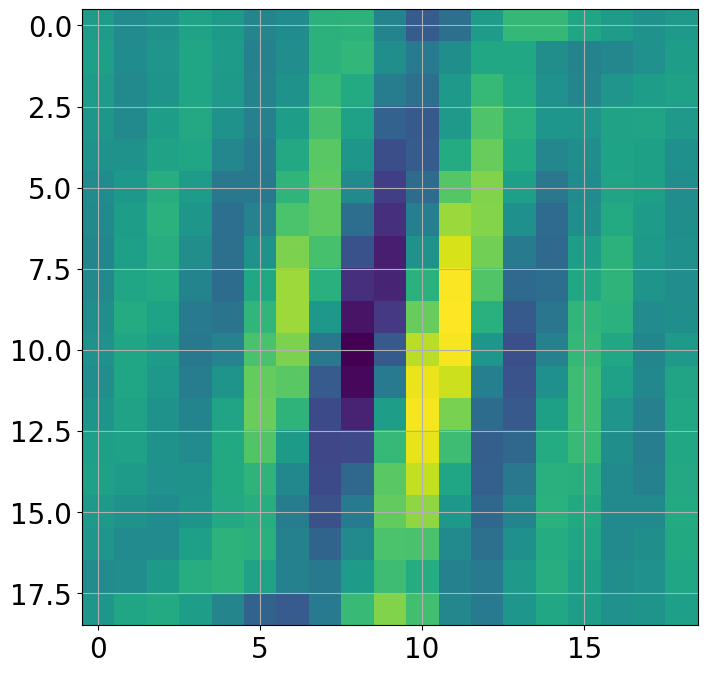

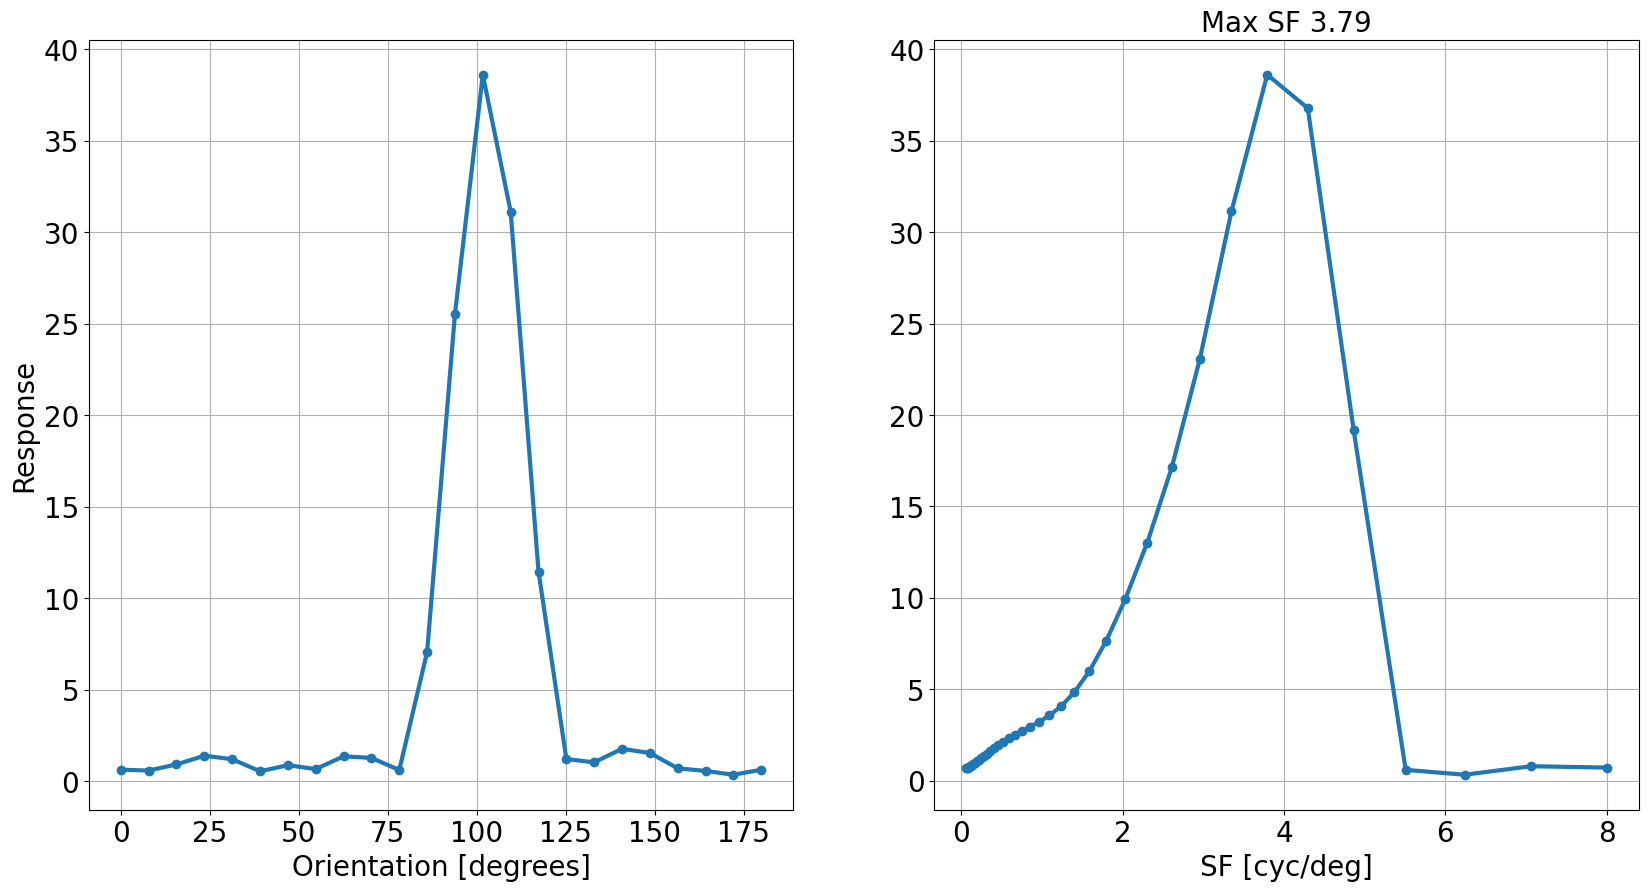

In [250]:
figure()
imshow(w)

figure(figsize=(20,10))
subplot(1,2,1)
plot(theta_mat,y[max_k_idx,:],'-o')
xlabel('Orientation [degrees]')
ylabel('Response')
subplot(1,2,2)


plot(cycles_per_degree,y[:,max_theta_idx],'-o')
xlabel('SF [cyc/deg]')
title(f'Max SF {cycles_per_degree[max_k_idx]:.2f}')


In [159]:
SF=cycles_per_degree
R_SF=y[:,max_theta_idx]
popt = fit_dog_model(SF, R_SF)
lsfv, SF_opt = compute_lsfv(popt)
lsfv

2.0556115296904833

In [160]:
len(R.all_responses)

1

In [161]:
t,y=R.all_responses[0] # k, theta, channel, neuron, time
y.shape

(20, 24, 1, 12, 193)

In [162]:
y=y.max(axis=1)  # optimize over theta
y.shape

(20, 1, 12, 193)

In [163]:
y1=y[:,0,:,-1] # last time
y1.shape

(20, 12)

(array([0.6460375 , 0.52445108, 0.75305156, 1.0356644 , 1.11830791,
        0.64464363, 0.81414902, 0.95166618, 0.97846631, 1.226707  ,
        0.71611773, 0.87696466]),
 array([ 4.39180089,  4.43247859,  3.85999362,  3.42400614,  3.58553986,
         4.04209584,  3.72023668,  3.82456972,  3.30003479, 88.7049689 ,
         3.42400614,  3.39258338]))

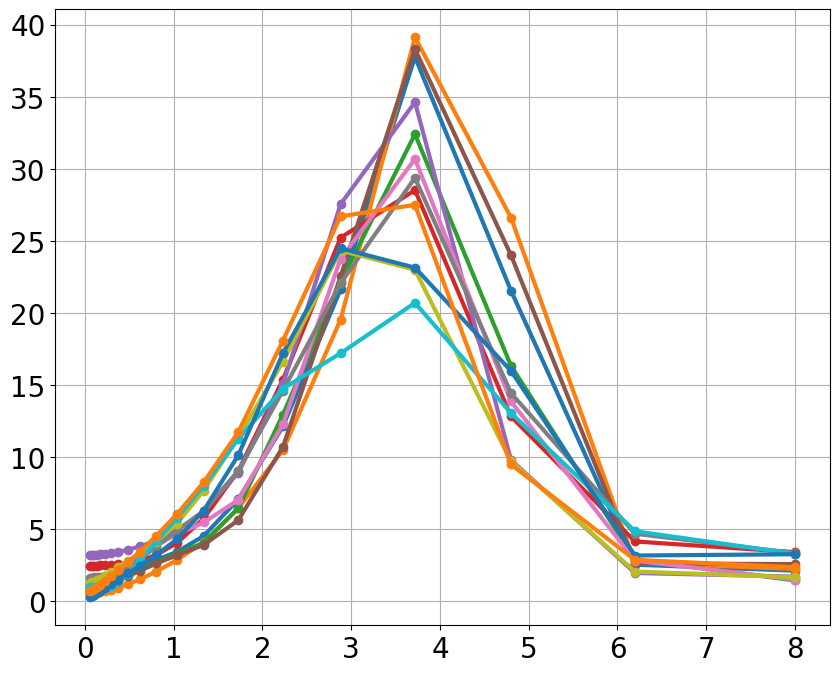

In [164]:
cycles_per_pixel=R.k_mat/2/pi
cycles_per_degree=cycles_per_pixel/deg_per_pixel
plot(cycles_per_degree,y1,'o-');

_S=Storage()
for n in range(y1.shape[1]):
    SF=cycles_per_degree
    R_SF=y1[:,n]
    popt = fit_dog_model(SF, R_SF)
    lsfv, SF_opt = compute_lsfv(popt)

    _S+=lsfv, SF_opt

lsfv, SF_opt=_S.arrays()
lsfv,SF_opt

## try for all time -- inefficient but it should work

In [165]:
t,y=R.all_responses[0] # k, theta, channel, neuron, time
y.shape

(20, 24, 1, 12, 193)

In [166]:
y=y.max(axis=1)  # optimize over theta
y.shape

(20, 1, 12, 193)

In [173]:
t,y=R.all_responses[0] # k, theta, channel, neuron, time
y=y.max(axis=1)  # optimize over theta

lsfv_mat=zeros((y.shape[1],y.shape[2],y.shape[3]))
SF_opt_mat=zeros((y.shape[1],y.shape[2],y.shape[3]))

cycles_per_pixel=R.k_mat/2/pi
cycles_per_degree=cycles_per_pixel/deg_per_pixel

for ti in tqdm(range(y.shape[3])):
    for c in range(y.shape[1]):
        for n in range(y.shape[2]):
            SF=cycles_per_degree
            R_SF=y[:,c,n,ti]
            try:
                popt = fit_dog_model(SF, R_SF)
                lsfv, SF_opt = compute_lsfv(popt)
            except RuntimeError:
                lsfv=100
                SF_opt=-1
                continue 
    
            lsfv_mat[c,n,ti]=lsfv
            SF_opt_mat[c,n,ti]=SF_opt

  0%|          | 0/193 [00:00<?, ?it/s]

In [175]:
lsfv_mat.shape

(1, 12, 193)

Text(0.5, 0, 'Time')

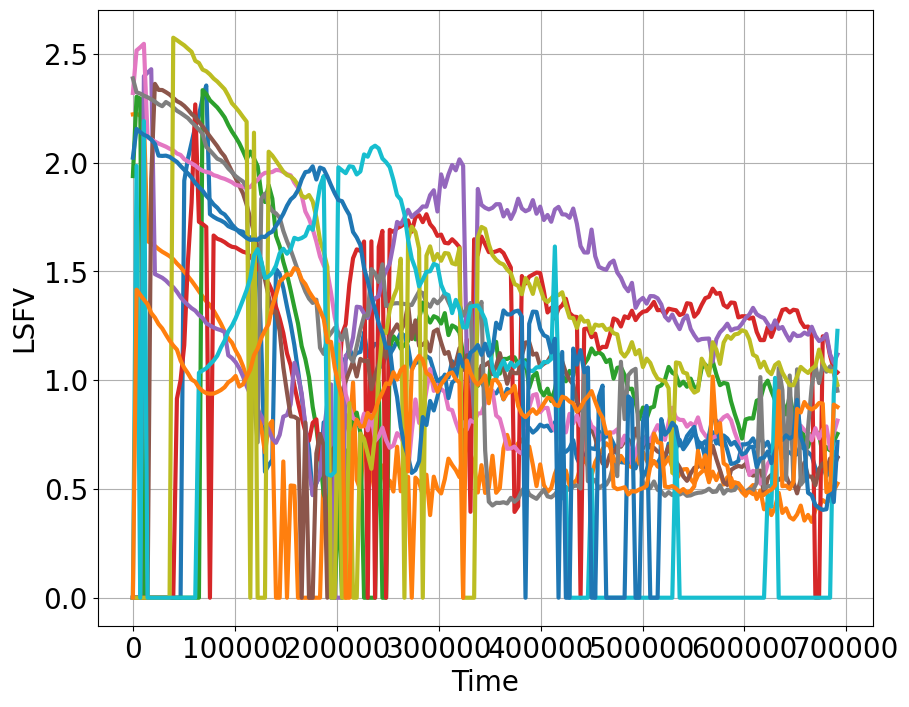

In [179]:
plot(R.t,lsfv_mat[0,:,:].T);
ylabel('LSFV')
xlabel('Time')

In [180]:
import numpy as np

def circular_variance(theta_deg, R_theta):
    """
    Compute circular variance for orientation tuning.
    
    Parameters:
        theta_deg (array): angles in degrees (0 to 180)
        R_theta (array): responses at each angle
        
    Returns:
        circ_var (float): circular variance (0 = sharply tuned, 1 = uniform)
    """
    # Convert to radians and double angles for orientation
    theta_rad = np.deg2rad(theta_deg)
    doubled_angles = 2 * theta_rad

    # Compute circular variance
    vector_sum = np.sum(R_theta * np.exp(1j * doubled_angles))
    norm = np.sum(R_theta)
    circ_var = 1 - np.abs(vector_sum / norm)
    return circ_var

In [181]:
t,y=R.all_responses[0] # k, theta, channel, neuron, time
y.shape

(20, 24, 1, 12, 193)

In [182]:
y=y.max(axis=0)  # optimize over k
y.shape

(24, 1, 12, 193)

In [187]:
theta=R.theta_mat
R_theta=y[:,0,-1,-1]
circular_variance(theta, R_theta)

0.3841417610477401

In [199]:
import numpy as np

def circular_variance_batch(theta_deg, R):
    """
    Compute circular variance over axis=0 of a 4D array:
    (angles, channels, neurons, time_points)

    Parameters:
        theta_deg: array of shape (angles,) — angles in degrees
        R: array of shape (angles, channels, neurons, time_points)

    Returns:
        circ_var: array of shape (channels, neurons, time_points)
    """
    # Convert angles to radians and double for orientation tuning
    theta_rad = np.deg2rad(theta_deg)
    doubled_angles = 2 * theta_rad  # (angles,)

    # Compute complex exponential term and reshape to broadcast
    exp_term = np.exp(1j * doubled_angles)[:, np.newaxis, np.newaxis, np.newaxis]  # (angles,1,1,1)
    
    # Weighted complex vector sum over orientation axis (axis=0)
    vector_sum = np.sum(R * exp_term, axis=0)  # (channels, neurons, time_points)
    norm = np.sum(R, axis=0)                   # (channels, neurons, time_points)

    # Avoid divide-by-zero
    with np.errstate(invalid='ignore', divide='ignore'):
        circ_var = 1 - np.abs(vector_sum / norm)
        circ_var = np.nan_to_num(circ_var, nan=1.0)  # Replace NaNs with 1 (uniform)

    return circ_var

Text(0.5, 0, 'Time')

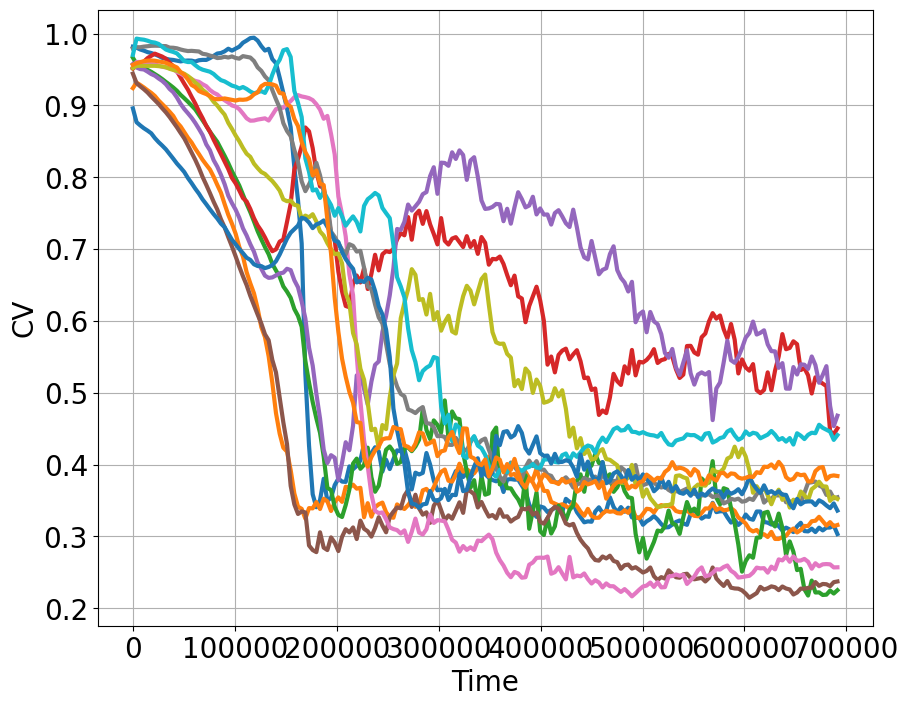

In [202]:
CV=circular_variance_batch(theta, y)
plot(R.t,CV[0,:,:].T);
ylabel('CV')
xlabel('Time')

https://pmc.ncbi.nlm.nih.gov/articles/PMC1665145/

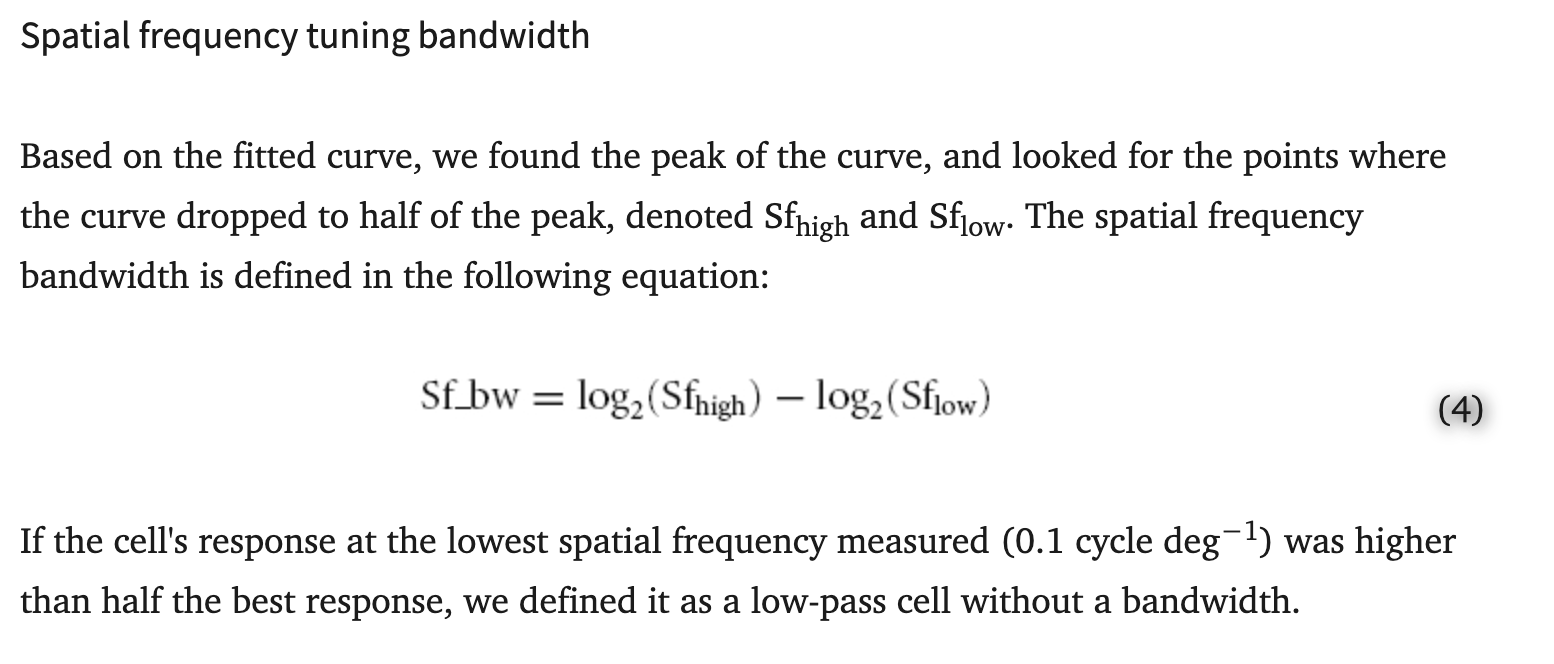

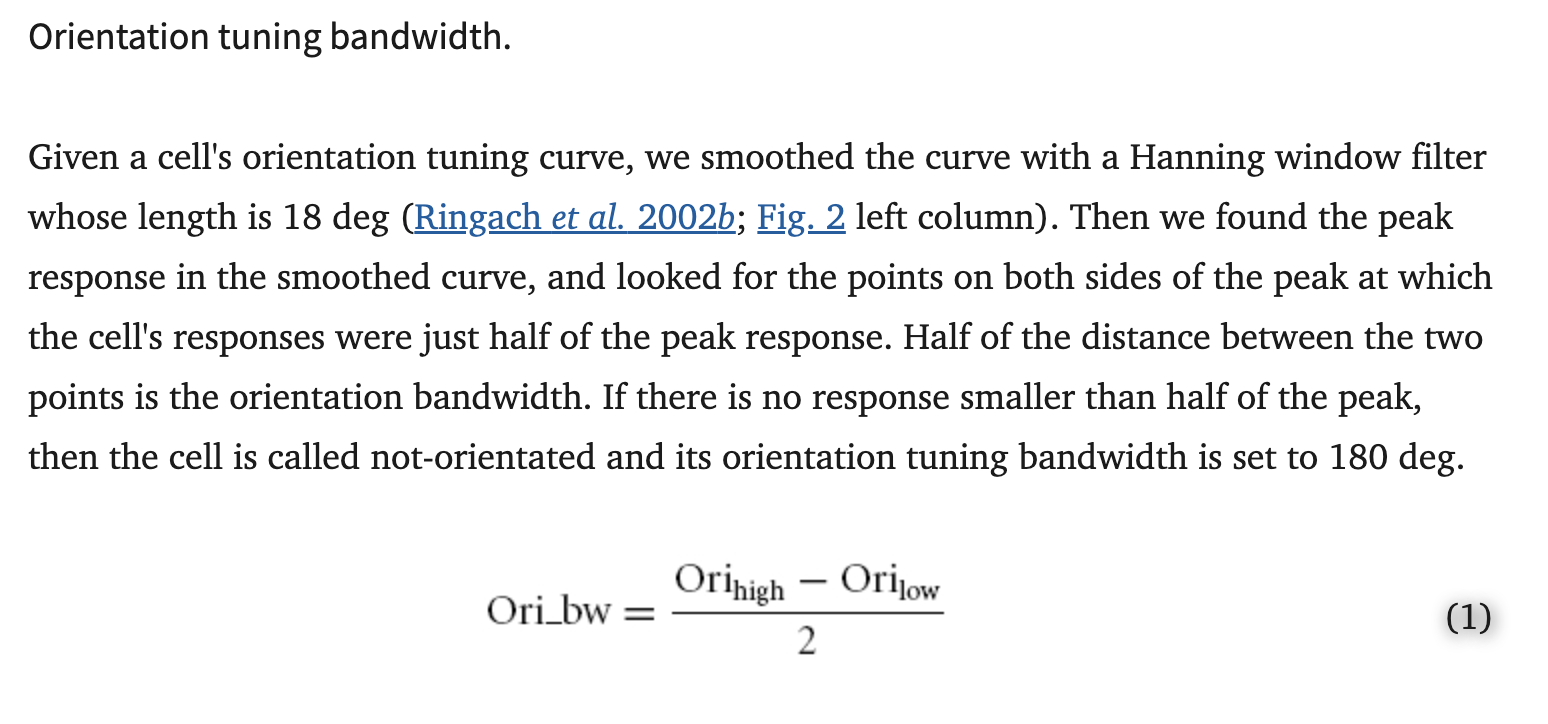

In [203]:
t,y=R.all_responses[0] # k, theta, channel, neuron, time
y.shape

(20, 24, 1, 12, 193)

In [204]:
y=y.max(axis=0)  # optimize over k
y.shape

(24, 1, 12, 193)

In [220]:
import numpy as np

def smooth_circular_curve(theta_deg, R_theta, window_deg=18):
    """
    Smooth a circular tuning curve using a Hanning window in degrees.
    
    Parameters:
        theta_deg: (N,) array of angles (degrees, uniformly spaced)
        R_theta: (N,) array of responses
        window_deg: smoothing window width in degrees (default = 18)
    
    Returns:
        R_smooth: (N,) array of smoothed responses
    """
    N = len(theta_deg)
    dtheta = np.mean(np.diff(theta_deg))

    # Convert window size to samples
    win_len = int(round(window_deg / dtheta))
    print(win_len)
    if win_len < 3:
        return R_theta.copy(),None  # no smoothing if window too small

    if win_len % 2 == 0:
        win_len += 1  # make it odd for symmetry

    # Create normalized Hanning window
    window = np.hanning(win_len)
    window /= window.sum()

    # Circular padding: wrap around the edges
    pad = win_len // 2
    R_padded = np.concatenate([R_theta[-pad:], R_theta, R_theta[:pad]])

    # Convolve and extract center part
    R_smooth = np.convolve(R_padded, window, mode='valid')  # now length = N

    return R_smooth,window

smoothing doesn't work

4


7.826086956521739

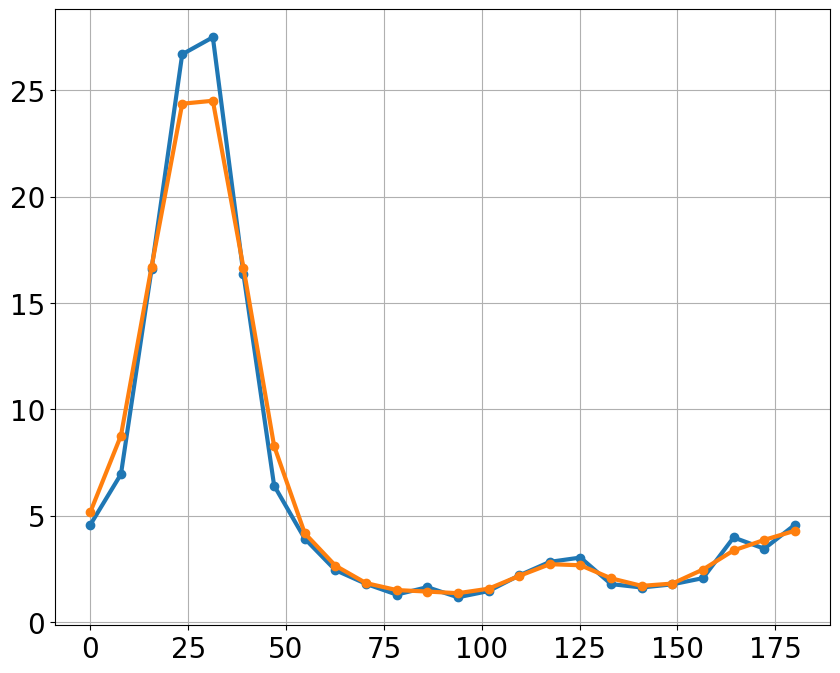

In [224]:
theta=R.theta_mat
R_theta=y[:,0,-1,-1]
plot(theta, R_theta,'-o')

R_smooth,window = smooth_circular_curve(theta, R_theta, window_deg=30)
plot(theta, R_smooth,'-o')
theta[1]-theta[0]

In [225]:
import numpy as np

def orientation_bandwidth(theta_deg, R_theta, smooth=True, window_deg=18):
    """
    Computes orientation tuning bandwidth (FWHM) in degrees.
    
    Parameters:
        theta_deg: array of orientation angles (0 to 180)
        R_theta: array of responses at each angle
        smooth: whether to smooth the curve with Hanning window
        window_deg: smoothing window width in degrees

    Returns:
        bandwidth_deg: full width at half maximum (FWHM) in degrees
    """
    if smooth:
        R_theta = smooth_circular_curve(theta_deg, R_theta, window_deg)

    # Normalize theta for circularity
    theta = np.array(theta_deg)
    R = np.array(R_theta)

    # Find peak response
    peak_idx = np.argmax(R)
    theta_peak = theta[peak_idx]
    R_peak = R[peak_idx]
    R_min = np.min(R)
    R_half = 0.5 * (R_peak + R_min)

    # Wrap theta and R to cover 0–360° for circular interpolation
    theta_extended = np.concatenate([theta - 180, theta, theta + 180])
    R_extended = np.concatenate([R, R, R])

    # Shift so theta_peak is centered at 180°
    shift = 180 - theta_peak
    theta_shifted = (theta_extended + shift) % 360
    sorted_idx = np.argsort(theta_shifted)
    theta_shifted = theta_shifted[sorted_idx]
    R_shifted = R_extended[sorted_idx]

    # Interpolate to finer grid
    theta_fine = np.linspace(0, 360, 1000)
    R_interp = np.interp(theta_fine, theta_shifted, R_shifted)

    # Find crossings at half-max
    above = R_interp > R_half
    edges = np.diff(above.astype(int))
    crossings = np.where(np.abs(edges) == 1)[0]

    if len(crossings) < 2:
        return np.nan  # No clear bandwidth found

    # Get FWHM around the center (180°)
    mid = np.argmin(np.abs(theta_fine - 180))
    closest = np.argsort(np.abs(crossings - mid))[:2]
    fwhm = np.abs(theta_fine[crossings[closest[1]]] - theta_fine[crossings[closest[0]]])
    return fwhm

In [229]:
orientation_bandwidth(theta, R_theta, smooth=False)

27.02702702702703

In [230]:
import numpy as np

def compute_fwhm_batch(theta_deg, R_4d):
    """
    Compute FWHM over 4D response array: (angles, channels, neurons, timepoints)

    Parameters:
        theta_deg: (A,) array of orientation angles (degrees, assumed uniform)
        R_4d: (A, C, N, T) array of responses

    Returns:
        FWHM: (C, N, T) array of full width at half maximum in degrees
    """
    A, C, N, T = R_4d.shape
    theta = np.asarray(theta_deg)
    dtheta = np.mean(np.diff(theta))  # assumes uniform spacing

    # Extend theta and R for circularity (0–180 deg)
    theta_ext = np.concatenate([theta - 180, theta, theta + 180])  # (3A,)
    R_ext = np.concatenate([R_4d, R_4d, R_4d], axis=0)  # (3A, C, N, T)

    # Shift so max is always centered
    R_max_idx = np.argmax(R_4d, axis=0)  # (C, N, T)
    theta_peak = theta[R_max_idx]  # (C, N, T)
    shift = 180 - theta_peak  # degrees to shift

    # Create fine theta grid
    theta_fine = np.linspace(0, 360, 1000)
    FWHM = np.full((C, N, T), np.nan)

    # Loop over C, N, T (can vectorize with jax or torch later)
    for c in range(C):
        for n in range(N):
            for t in range(T):
                # Extract extended curve and shift it
                R_curve = R_ext[:, c, n, t]
                theta_shifted = (theta_ext + shift[c, n, t]) % 360

                # Sort for interpolation
                sort_idx = np.argsort(theta_shifted)
                R_sorted = R_curve[sort_idx]
                theta_sorted = theta_shifted[sort_idx]

                # Interpolate to fine grid
                R_interp = np.interp(theta_fine, theta_sorted, R_sorted)

                # Find half-max
                R_max = np.max(R_interp)
                R_min = np.min(R_interp)
                R_half = 0.5 * (R_max + R_min)

                above = R_interp > R_half
                edges = np.diff(above.astype(int))
                crossings = np.where(np.abs(edges) == 1)[0]

                if len(crossings) >= 2:
                    # Closest pair around 180°
                    mid = np.argmin(np.abs(theta_fine - 180))
                    closest = np.argsort(np.abs(crossings - mid))[:2]
                    fwhm = np.abs(theta_fine[crossings[closest[1]]] - theta_fine[crossings[closest[0]]])
                    FWHM[c, n, t] = fwhm

    return FWHM

In [232]:
FWHM=compute_fwhm_batch(R.theta_mat, y)
FWHM.shape

(1, 12, 193)

Text(0.5, 0, 'Time')

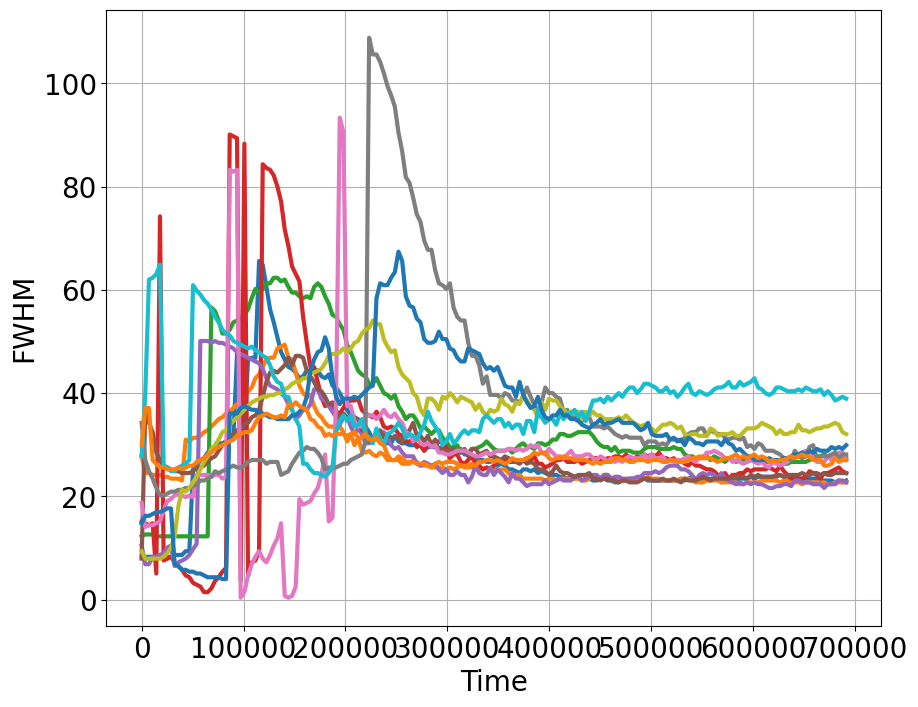

In [234]:
plot(R.t,FWHM[0,:,:].T);
ylabel('FWHM')
xlabel('Time')

In [235]:
R.max_SF.shape

(193, 12, 1)

Text(0.5, 0, 'Time')

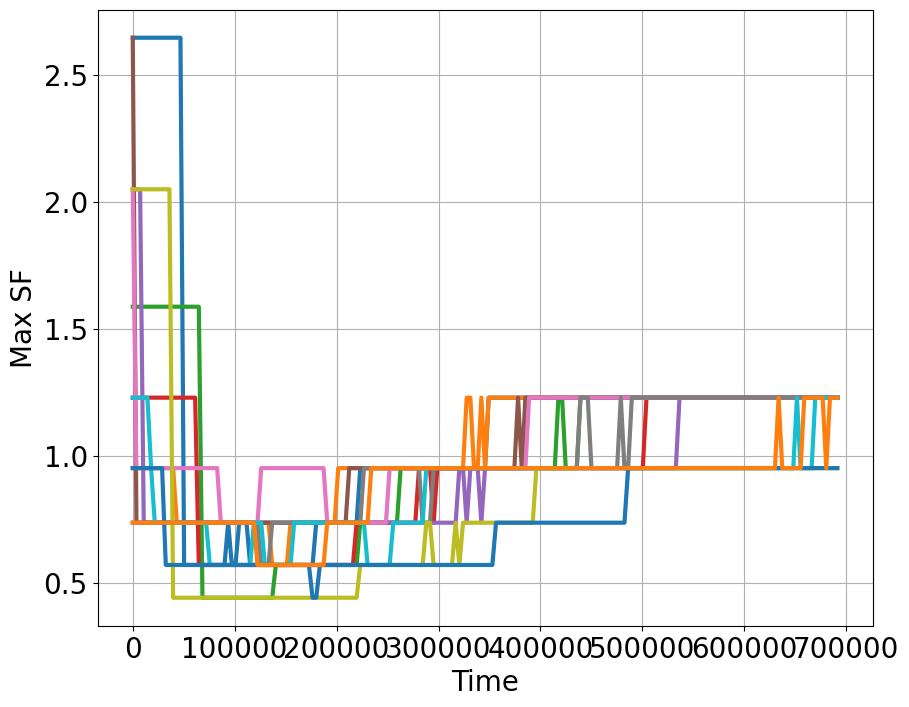

In [237]:
plot(R.t,R.max_SF[:,:,0]);
ylabel('Max SF')
xlabel('Time')

## interpolated

In [128]:
target_shape=(512, 512)
zoom_factors = (target_shape[0] / 19, target_shape[1] / 19)
modulator = w
modulator_resized = zoom(modulator, zoom_factors, order=1)

ww=modulator_resized

rf_diameter=ww.shape[0]
rf_area=rf_diameter*rf_diameter
rf_radius=rf_diameter//2

theta_mat=linspace(0.0,180,24)

cpd=2**linspace(-4,3,40)
deg_per_pixel=1/rf_diameter  # <=============
k_mat=2*pi*cpd*deg_per_pixel


cycles_per_pixel=k_mat/2/pi
cycles_per_degree=cycles_per_pixel/deg_per_pixel

numang=len(theta_mat)
num_k=len(k_mat)

j,i=meshgrid(arange(rf_diameter),arange(rf_diameter))
responses=zeros((num_k,numang))


for ki,k in enumerate(k_mat):
    for ai,th in enumerate(theta_mat):
        a=3.14159265-th/180.0*3.14159265
        kx=k*cos(a)
        ky=k*sin(a)

        ds=sin(kx*(i-rf_radius)+ ky*(j-rf_radius))
        dc=cos(kx*(i-rf_radius)+ ky*(j-rf_radius))
        
        cs=(ww*ds).sum() # response to sin/cos grating input
        cc=(ww*dc).sum()
        
        phi=atan2(cc,cs)  # phase to give max response
        c=cs*cos(phi)+cc*sin(phi)     # max response

        responses[ki,ai]=c

y=responses

idx=argmax(y)  # max across all angles and SF
i,j=meshgrid(range(len(theta_mat)),range(len(k_mat)))
max_k_idx=j.ravel()[idx]
max_theta_idx=i.ravel()[idx]

max_k=k_mat[max_k_idx]
max_theta=theta_mat[max_theta_idx]
max_k,max_theta

(0.03628705270182178, 101.73913043478261)

Text(0.5, 1.0, 'Max SF 2.96')

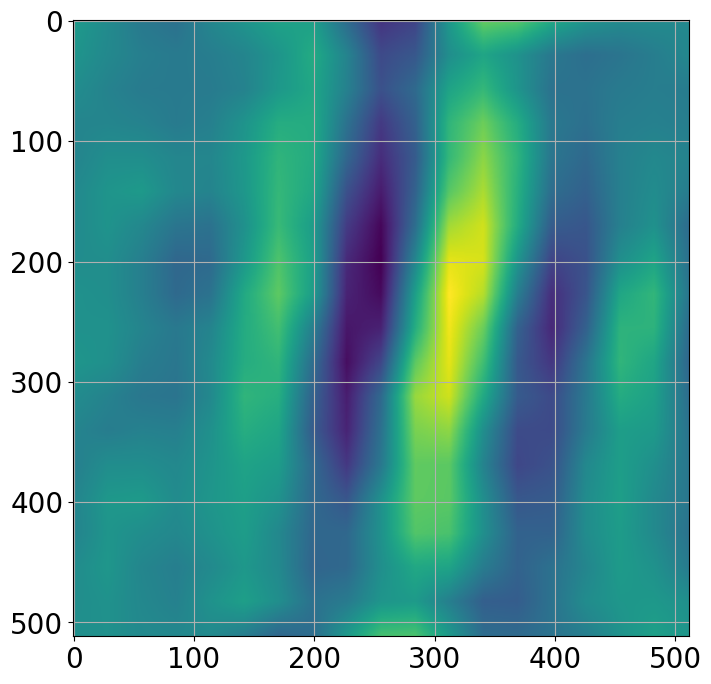

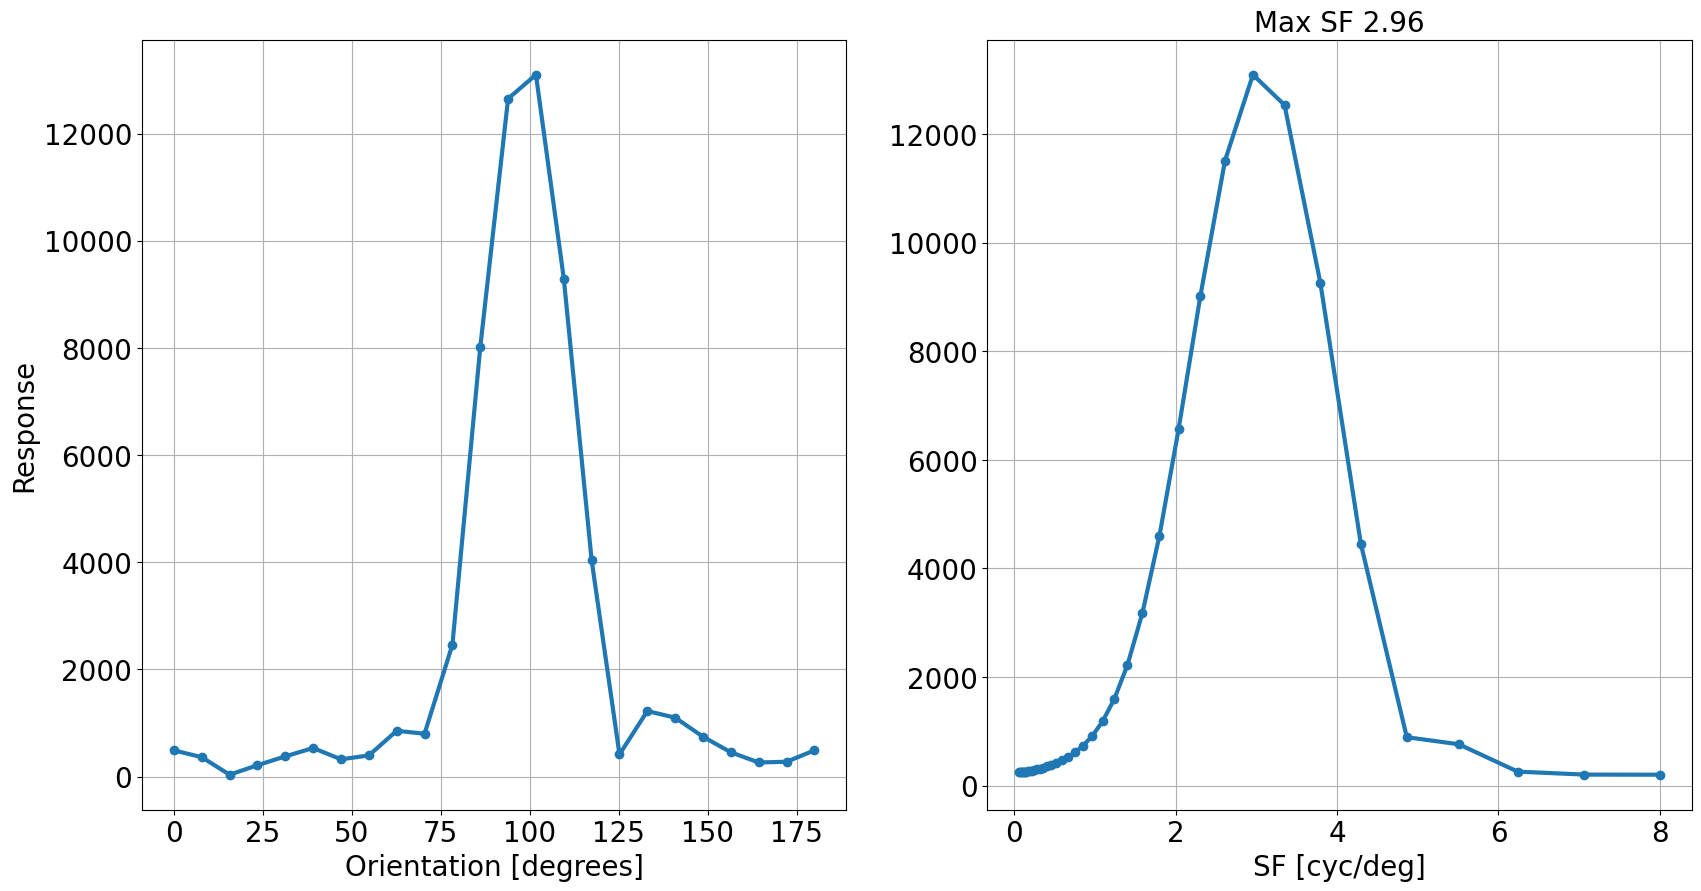

In [129]:
figure()
imshow(ww)

figure(figsize=(20,10))
subplot(1,2,1)
plot(theta_mat,y[max_k_idx,:],'-o')
xlabel('Orientation [degrees]')
ylabel('Response')
subplot(1,2,2)


plot(cycles_per_degree,y[:,max_theta_idx],'-o')
xlabel('SF [cyc/deg]')
title(f'Max SF {cycles_per_degree[max_k_idx]:.2f}')


In [131]:
SF=cycles_per_degree
R_SF=y[:,max_theta_idx]

In [132]:
popt = fit_dog_model(SF, R_SF)
lsfv, SF_opt = compute_lsfv(popt)
lsfv

0.5118867066565056

lsfv for w0 2.0556115296904833

lsfv for w1 0.5118

LSFV has a value of 0 for the most tuned cells; for an untuned, low-pass neuron LSFV is equal to 1/3 (as shown in Xing et al. 2004 with examples of data).